In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install -U tensorflow
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

In [6]:
df = pd.read_csv('/content/international-migration-october-2025-citizenship-by-visa-and-by-country-of-last-permanent-residence.csv', index_col='year_month', parse_dates=True)
df['estimate'] = pd.to_numeric(df['estimate'], errors='coerce')
df.dropna(subset=['estimate'], inplace=True)

data_to_scale = df['estimate'].values.reshape(-1, 1)

# Same 12-month test period as SARIMA
test_size = 12

train_data = data_to_scale[:-test_size]
test_data = data_to_scale[-test_size:]

# Fit scaler ONLY on training data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [7]:
# 2. Sequence Creation (Windowing)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12

# Training sequences
X_train, y_train = create_sequences(train_scaled, window_size)

# Test sequences need the final 12 training months as context
test_context = np.concatenate(
    [train_scaled[-window_size:], test_scaled],
    axis=0
)

X_test, y_test = create_sequences(test_context, window_size)

In [10]:
# 3. Build and Train LSTM Model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)

Epoch 1/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 4.6127e-05
Epoch 2/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 3.3471e-05
Epoch 3/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 3.1890e-05
Epoch 4/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 3.1717e-05
Epoch 5/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 3.1606e-05
Epoch 6/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 3.0191e-05
Epoch 7/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 2.9405e-05
Epoch 8/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - loss: 2.8829e-05
Epoch 9/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 2.7884e-05
Epoch 10/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 2.6894e-05
Epoch 11/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - loss: 2.6121e-05
Epoch 12/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 2.5530e-05
Epoch 13/30
22318/22318 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - loss: 2.5412e-05
Epoch 14

In [11]:
# 4. Evaluation
predictions = model.predict(X_test)
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


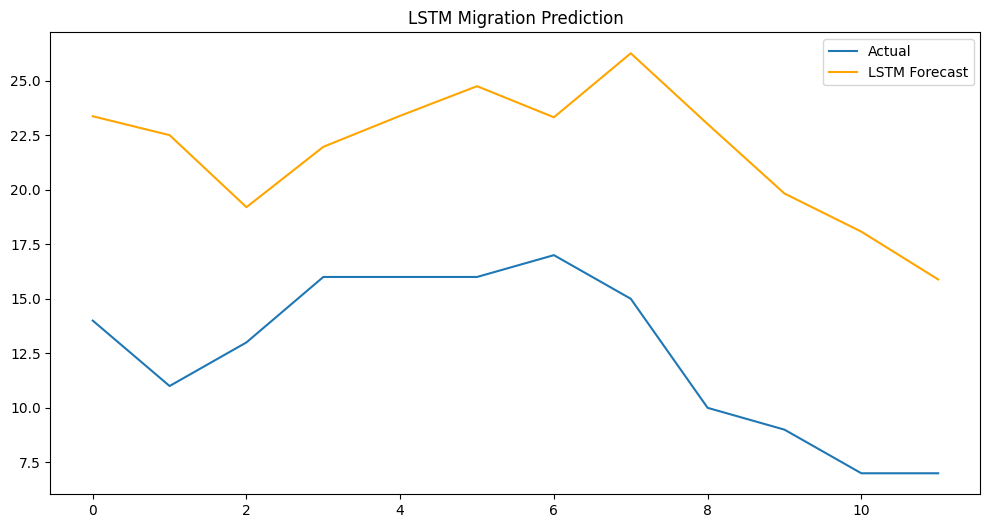

Test RMSE: 9.49


In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(predictions_inv, label='LSTM Forecast', color='orange')
plt.title('LSTM Migration Prediction')
plt.legend()
plt.show()

rmse = np.sqrt(mean_squared_error(y_test_inv, predictions_inv))
print(f'Test RMSE: {rmse:.2f}')